In [4]:
# Celda 1: Importar librerías
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar la carpeta raíz al path para poder importar 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from cargar_datos import cargar_dataset_abandono
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier

# Configuración de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [5]:
# Celda 2: Cargar el dataset directamente desde SQL Server
print("🔄 Conectando a SQL Server y cargando datos...")
df = cargar_dataset_abandono()

if df is not None:
    print(f"✅ Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")
else:
    print("❌ Error al cargar datos. Revisa tu archivo .env y la conexión a SQL Server.")

🔄 Conectando a SQL Server y cargando datos...
📊 CARGANDO DATASET DE ABANDONO
✅ Conexión exitosa a SQL Server
✅ Consulta ejecutada: 3,040 registros, 27 columnas

📏 Dimensiones: 3,040 filas × 27 columnas

🎯 Distribución de la variable target:
es_abandono
1    1780
0    1260
Name: count, dtype: int64

📈 Tasa de abandono: 58.55%
✅ Datos cargados: 3040 filas, 27 columnas


In [6]:
# Celda 3: Preparar variables para el modelo (VERSIÓN SIMPLE)

# 1. Eliminar columnas que no son predictivas
columnas_a_eliminar = ['id_reserva', 'id_cliente', 'fecha_inicio_reserva', 'es_abandono']
X = df.drop(columns=columnas_a_eliminar, errors='ignore')
y = df['es_abandono']

# 2. Las variables categóricas ya están codificadas como binarias en SQL:
#    - es_ocasional_promo, es_estudiante, es_cliente_nuevo
#    - es_app_movil, es_internacional, es_ruta_MGA_MIA, etc.
# 3. Solo necesitamos verificar si queda alguna columna de texto
columnas_texto = X.select_dtypes(include=['object']).columns

if len(columnas_texto) > 0:
    print(f"⚠️ Columnas de texto detectadas: {list(columnas_texto)}")
    X = pd.get_dummies(X, columns=columnas_texto.tolist(), drop_first=True)
else:
    print("✅ Todas las variables ya son numéricas (no se necesita encoding)")

# 4. Convertir booleanos a enteros
X = X.astype({col: 'int8' for col in X.select_dtypes(include=['bool']).columns})

# 5. Rellenar valores nulos
X = X.fillna(0)

print(f"\n✅ Features finales: {X.shape[1]} columnas")
print(f"📋 Lista de variables: {list(X.columns)}")

⚠️ Columnas de texto detectadas: ['segmento_cliente']

✅ Features finales: 27 columnas
📋 Lista de variables: ['hora_inicio', 'es_horario_nocturno', 'dia_semana', 'es_fin_semana', 'es_temporada_alta', 'intentos_pago_fallidos', 'reservas_mismo_dia', 'es_app_movil', 'es_web_desktop', 'es_sucursal', 'es_internacional', 'es_ruta_MGA_MIA', 'es_ruta_top5', 'precio_cotizado', 'precio_vs_promedio_ruta', 'es_precio_alto_intl', 'antiguedad_cliente_dias', 'es_cliente_nuevo', 'compras_previas_12m', 'monto_total_12m', 'es_ocasional_promo', 'es_estudiante', 'segmento_cliente_Familias Premium', 'segmento_cliente_Millennials Digitales', 'segmento_cliente_Ocasional Promo', 'segmento_cliente_Otros', 'segmento_cliente_Viajeros de Negocios']


In [7]:
# Celda 4: Dividir en entrenamiento (80%) y prueba (20%)
# stratify=y asegura que la proporción de abandonos sea igual en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"✅ Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")

✅ Train: 2432 registros | Test: 608 registros


In [8]:
# Celda 5: Entrenar el modelo
# scale_pos_weight corrige el desbalance de clases (clase 1 / clase 0)
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

modelo = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=ratio_desbalance, # Clave para datos desbalanceados
    random_state=42,
    eval_metric='auc'
)

print("🔄 Entrenando modelo XGBoost... (esto puede tomar unos segundos)")
modelo.fit(X_train, y_train)
print("✅ Modelo entrenado exitosamente")

🔄 Entrenando modelo XGBoost... (esto puede tomar unos segundos)


D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\EjemploMineria\DataSetGenerator\skytravel-analytics\venv\lib\site-packages\xgboost\data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\EjemploMineria\DataSetGenerator\skytravel-analytics\venv\lib\site-packages\xgboost\data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\EjemploMineria\DataSetGenerator\skytravel-analytics\venv\lib\site-packages\xgboost\data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\

✅ Modelo entrenado exitosamente


In [9]:
# Celda 6: Evaluar rendimiento en el set de prueba
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

print("=" * 60)
print("📊 REPORTE DE CLASIFICACIÓN")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Pagada (0)', 'Abandonada (1)']))

print(f"🎯 ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

📊 REPORTE DE CLASIFICACIÓN
                precision    recall  f1-score   support

    Pagada (0)       1.00      0.98      0.99       252
Abandonada (1)       0.99      1.00      0.99       356

      accuracy                           0.99       608
     macro avg       0.99      0.99      0.99       608
  weighted avg       0.99      0.99      0.99       608

🎯 ROC-AUC Score: 1.0000


D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\EjemploMineria\DataSetGenerator\skytravel-analytics\venv\lib\site-packages\xgboost\data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\EjemploMineria\DataSetGenerator\skytravel-analytics\venv\lib\site-packages\xgboost\data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\EjemploMineria\DataSetGenerator\skytravel-analytics\venv\lib\site-packages\xgboost\data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\

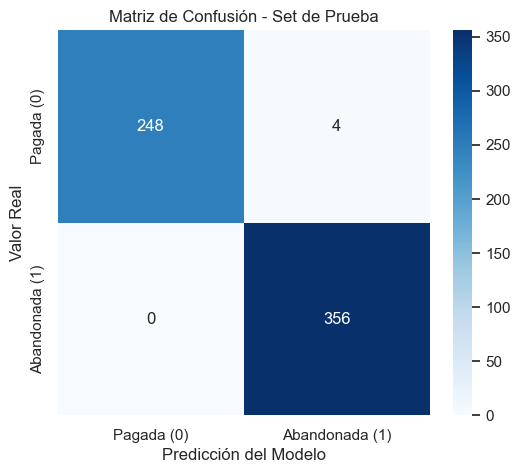

In [10]:
# Celda 7: Gráfico de Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pagada (0)', 'Abandonada (1)'], 
            yticklabels=['Pagada (0)', 'Abandonada (1)'])
plt.title('Matriz de Confusión - Set de Prueba')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\EjemploMineria\DataSetGenerator\skytravel-analytics\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\EjemploMineria\DataSetGenerator\skytravel-analytics\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
D:\DOCUMENTOS\CARPETA DOCENTE\MINERIA DE DATOS\EjemploMineria\DataSetGenerator\skytravel-analytics\venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vect

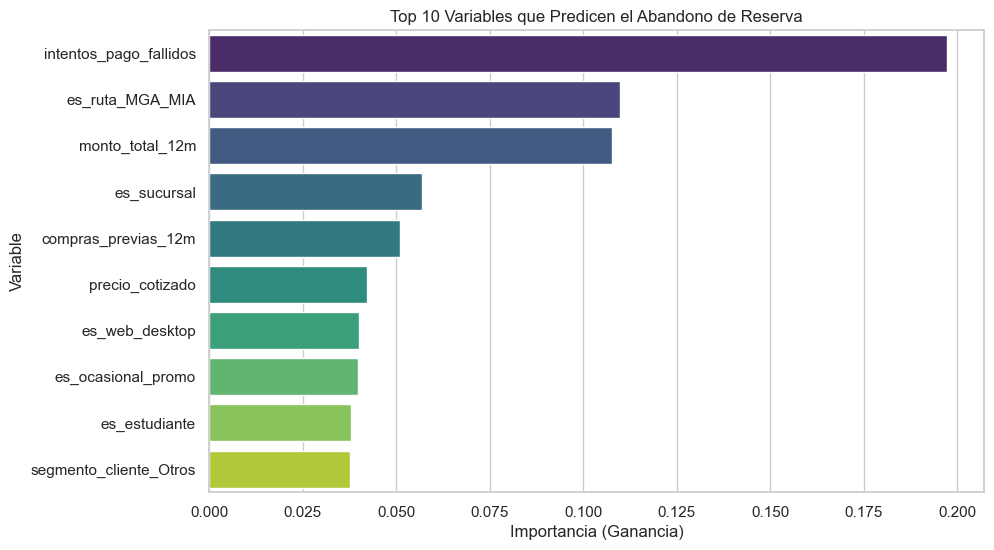

In [11]:
# Celda 8: ¿Qué variables causan más el abandono?
importancia = modelo.feature_importances_
features = X.columns

# Crear DataFrame y ordenar
df_importancia = pd.DataFrame({'Variable': features, 'Importancia': importancia})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Top 10 Variables que Predicen el Abandono de Reserva')
plt.xlabel('Importancia (Ganancia)')
plt.ylabel('Variable')
plt.show()